Covariance Matrix:
 [[137  76 107 182]
 [ 76  80 124 112]
 [107 124 194 161]
 [182 112 161 245]]
U matrix:
 [[-0.01589143 -0.62473572 -0.78053689  0.01465965]
 [ 0.67424727 -0.124659    0.09959134  0.72106332]
 [ 0.07605156  0.77053141 -0.61551284  0.14711034]
 [-0.7344074  -0.02113668  0.04458333  0.67691309]]

Singular values:
 [1.25507335e+02 7.54447404e+01 1.02821149e-14 1.31377154e-15]

V transpose:
 [[-0.60919917 -0.16007991 -0.17193665 -0.75742233]
 [-0.21821128  0.473538    0.84532929 -0.11646458]
 [ 0.73390222 -0.22725677  0.23470418 -0.59552988]
 [ 0.2065133   0.83575747 -0.4480738  -0.24102194]]


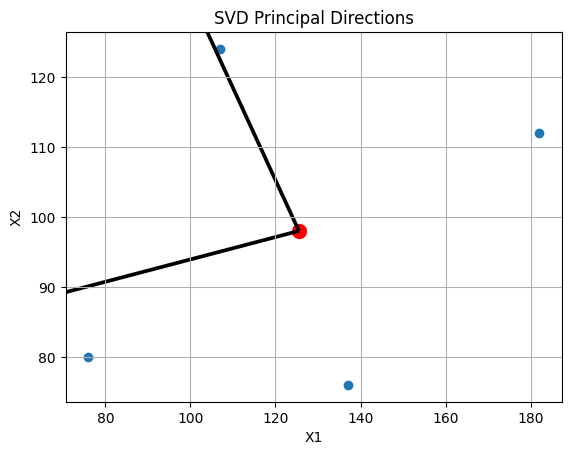

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([
    [4, 11],
    [8, 4],
    [13, 5],
    [7, 14]
])

X_t = X.T
X = X @ X_t
print("Covariance Matrix:\n", X)
# Step 1: Mean center
mean = np.mean(X, axis=0)
X_centered = X - mean

# Step 2: Apply SVD
U, S, Vt = np.linalg.svd(X_centered)

print("U matrix:\n", U)
print("\nSingular values:\n", S)
print("\nV transpose:\n", Vt)

# Principal components (rows of Vt)
PC1 = Vt[0]
PC2 = Vt[1]

# Plot original data
plt.scatter(X[:,0], X[:,1])
plt.scatter(mean[0], mean[1], color='red', s=100)

# Draw PC directions
plt.quiver(mean[0], mean[1], PC1[0]*5, PC1[1]*5, scale=1)
plt.quiver(mean[0], mean[1], PC2[0]*5, PC2[1]*5, scale=1)

plt.title("SVD Principal Directions")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid()
plt.show()

SVD Components (like Vt):
 [[-0.55738997  0.83025082]
 [ 0.83025082  0.55738997]]

Singular Values:
 [9.54749145 4.45481841]


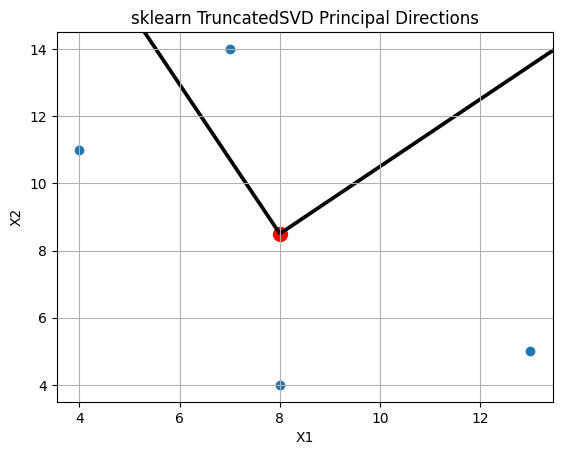

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# Dataset
X = np.array([
    [4, 11],
    [8, 4],
    [13, 5],
    [7, 14]
])

# Mean center (important for PCA-style SVD)
mean = np.mean(X, axis=0)
X_centered = X - mean

# sklearn SVD
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_centered)

# Components (like Vt in numpy SVD)
Vt = svd.components_

print("SVD Components (like Vt):\n", Vt)
print("\nSingular Values:\n", svd.singular_values_)

PC1 = Vt[0]
PC2 = Vt[1]

# Visualization
plt.scatter(X[:,0], X[:,1])
plt.scatter(mean[0], mean[1], color='red', s=100)

plt.quiver(mean[0], mean[1], PC1[0]*5, PC1[1]*5, scale=1)
plt.quiver(mean[0], mean[1], PC2[0]*5, PC2[1]*5, scale=1)

plt.title("sklearn TruncatedSVD Principal Directions")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid()
plt.show()


In [10]:
import numpy as np

X = np.array([
    [4, 11],
    [8, 4],
    [13, 5],
    [7, 14]
])

# Mean center
mean = np.mean(X, axis=0)
X_centered = X - mean

# Covariance matrix
n = X.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 14. -11.]
 [-11.  23.]]


In [11]:
# SVD on centered ORIGINAL DATA (not covariance)
U, S, Vt = np.linalg.svd(X_centered)

print("\nU:\n", U)
print("\nSingular Values:\n", S)
print("\nVt:\n", Vt)



U:
 [[ 0.45092336  0.43268393  0.77259596 -0.11201882]
 [-0.39132045  0.56304312  0.01857209  0.72767151]
 [-0.59626424 -0.49393466  0.63121649  0.04542312]
 [ 0.53666133 -0.5017924   0.06569858  0.67519086]]

Singular Values:
 [9.54749145 4.45481841]

Vt:
 [[-0.55738997  0.83025082]
 [-0.83025082 -0.55738997]]
